# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Telco Customer Churn (IBM Dataset)** https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset. Dataset ini memiliki 7.043 baris dan 33 kolom. Target klasifikasi adalah `Churn Value` (1 = Churn, 0 = Retained) untuk memprediksi apakah seorang pelanggan akan berhenti menggunakan layanan telekomunikasi atau tidak.

# **2. Import Library**

Mengimpor beberapa pustaka utama seperti pandas, numpy, matplotlib, seaborn, dan scikit-learn untuk membantu analisis data, visualisasi, dan rekayasa fitur.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Library successfully imported!")

Library successfully imported!


# **3. Memuat Dataset**

Memuat dataset Excel mentah dari folder `Telco_customer_churn_raw`.

In [2]:
raw_path = '../Telco_customer_churn_raw/Telco_customer_churn_raw.xlsx'
df = pd.read_excel(raw_path)
print(f"Shape of dataset: {df.shape}")
df.head().T

Shape of dataset: (7043, 33)


,0,1,2,3,4
CustomerID,3668-QPYBK,9237-HQITU,9305-CDSKC,7892-POOKP,0280-XJGEX
Count,1,1,1,1,1
Country,United States,United States,United States,United States,United States
State,California,California,California,California,California
City,Los Angeles,Los Angeles,Los Angeles,Los Angeles,Los Angeles
Zip Code,90003,90005,90006,90010,90015
Lat Long,"33.964131, -118.272783","34.059281, -118.30742","34.048013, -118.293953","34.062125, -118.315709","34.039224, -118.266293"
Latitude,33.964131,34.059281,34.048013,34.062125,34.039224
Longitude,-118.272783,-118.30742,-118.293953,-118.315709,-118.266293
Gender,Male,Female,Female,Female,Male


### **Penjelasan Hasil Output:**
Output menunjukkan bahwa data mentah berhasil dimuat dengan dimensi **7043 baris dan 33 kolom**. Lima baris awal menampilkan struktur data yang mencakup ID pelanggan (`CustomerID`), informasi demografis (`Gender`, `Senior Citizen`), informasi layanan (`Internet Service`, `Tech Support`), informasi keuangan (`Monthly Charges`, `Total Charges`), serta label target (`Churn Value` dan `Churn Label`).

# **4. Exploratory Data Analysis (EDA)**

Melakukan EDA untuk memahami tipe data, mendeteksi missing values, dan melihat distribusi dari fitur-fitur penting.

In [3]:
# Informasi tipe data dan missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### **Penjelasan Hasil Output:**
Mengidentifikasi bahwa sebagian besar kolom bertipe `object` (kategorikal) dan terdapat beberapa kolom bertipe `float64` atau `int64` (numerik). Yang menarik, `Total Charges` terdeteksi sebagai tipe `object` (seharusnya numerik), mengindikasikan adanya spasi kosong di dalamnya. Dari sisi missing values, hanya kolom `Churn Reason` yang memiliki nilai null secara eksplisit karena hanya diisi oleh pelanggan yang melakukan churn.

In [4]:
# Memeriksa deskripsi statistik fitur numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


### **Penjelasan Hasil Output:**
Statistik deskriptif menunjukkan rentang nilai dari variabel numerik seperti `Tenure Months` (rata-rata 32.37 bulan) dan `Monthly Charges` (rata-rata 64.76 USD). Nilai rata-rata dari target `Churn Value` adalah 0.265, yang menandakan bahwa sekitar **26.5%** dari total sampel merupakan pelanggan yang churn.

C:\Users\mfala\AppData\Local\Temp\ipykernel_11200\296031458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn Value', data=df, palette='Set2')


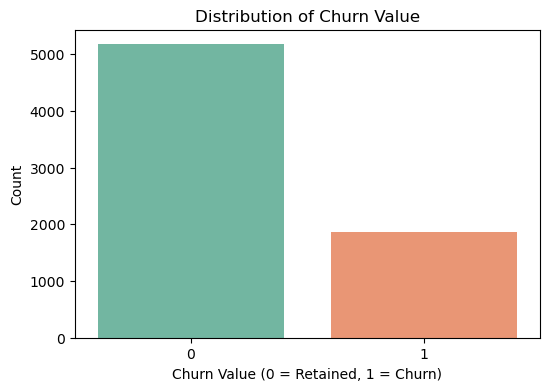

In [5]:
# Distribusi target Churn Value
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn Value', data=df, palette='Set2')
plt.title('Distribution of Churn Value')
plt.xlabel('Churn Value (0 = Retained, 1 = Churn)')
plt.ylabel('Count')
plt.show()

### **Penjelasan Hasil Output:**
Grafik batang distribusi target (`Churn Value`) menunjukkan ketidakseimbangan kelas (*class imbalance*). Jumlah pelanggan yang tetap berlangganan (0) jauh lebih banyak dibandingkan pelanggan yang berhenti (1).

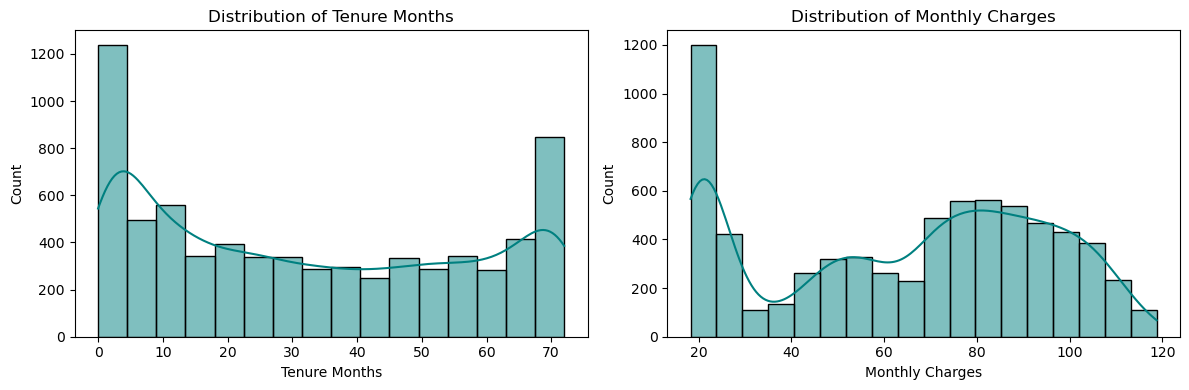

In [6]:
# Distribusi fitur numerik utama
num_cols = ['Tenure Months', 'Monthly Charges']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### **Penjelasan Hasil Output:**
*   Distribusi **`Tenure Months`** menunjukkan pola bimodal dengan puncak tinggi di bulan-bulan awal (pelanggan baru) dan bulan-bulan akhir (pelanggan setia jangka panjang).
*   Distribusi **`Monthly Charges`** menunjukkan konsentrasi tinggi pada tagihan rendah (sekitar 20 USD) yang merepresentasikan paket dasar, diikuti penyebaran merata pada paket premium lainnya.

# **5. Data Preprocessing & Splitting**

Untuk mencegah kebocoran data (*data leakage*), tahapan preprocessing diatur dengan urutan:
1.  **Row-Wise Cleaning:** Membersihkan nilai kosong di `Total Charges` (proses per baris tidak menyebabkan leakage).
2.  **Feature Selection:** Menghapus kolom leakage (`Churn Score`, `CLTV`, `Churn Reason`, `Churn Label`) dan kolom tidak relevan.
3.  **Train-Test Split:** Memisahkan data menjadi Train (80%) dan Test (20%) secara acak dan terstratifikasi.
4.  **Fit & Transform Preprocessing:** Membuat Scaler dan Encoder, men-**fit** hanya pada data Train, kemudian men-**transform** data Train dan Test.

In [7]:
# 1. Clean Total Charges
df['Total Charges'] = df['Total Charges'].astype(str).str.strip()
df['Total Charges'] = df['Total Charges'].replace('', '0')
df['Total Charges'] = pd.to_numeric(df['Total Charges'])
print("Total Charges dtype:", df['Total Charges'].dtype)
print("Number of empty Total Charges values resolved:", (df['Total Charges'] == 0).sum())

Total Charges dtype: float64
Number of empty Total Charges values resolved: 11


### **Penjelasan Hasil Output:**
Tipe data kolom `Total Charges` berhasil dikonversi menjadi numerik (`float64`) setelah 11 spasi kosong (untuk pelanggan baru dengan tenure 0 bulan) berhasil diubah menjadi nilai `0`.

In [8]:
# 2. Drop leakage & irrelevant columns
cols_to_drop = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 
    'Churn Score', 'CLTV', 'Churn Reason'
]
df_clean = df.drop(columns=cols_to_drop)
print(f"Shape after dropping columns: {df_clean.shape}")
print("Remaining columns:", df_clean.columns.tolist())

Shape after dropping columns: (7043, 20)
Remaining columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


### **Penjelasan Hasil Output:**
Kolom target leakage (`Churn Score`, `CLTV`, `Churn Reason`, `Churn Label`) dan kolom tidak informatif/konstan (`CustomerID`, `Count`, `Country`, etc.) berhasil dihapus. Jumlah kolom berkurang dari **33** menjadi **20** kolom.

In [9]:
# 3. Memisahkan Features dan Target
X = df_clean.drop(columns=['Churn Value'])
y = df_clean['Churn Value']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (7043, 19), y shape: (7043,)


### **Penjelasan Hasil Output:**
Features (`X`, 19 kolom) dan target label (`y`, 1 kolom) berhasil dipisahkan untuk persiapan pemisahan dataset.

In [10]:
# 4. Train-Test Split (Pemisahan Dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print("Target proportions in train:", y_train.value_counts(normalize=True).to_dict())
print("Target proportions in test:", y_test.value_counts(normalize=True).to_dict())

X_train shape: (5634, 19), y_train shape: (5634,)
X_test shape: (1409, 19), y_test shape: (1409,)
Target proportions in train: {0: 0.7346467873624423, 1: 0.2653532126375577}
Target proportions in test: {0: 0.7345635202271115, 1: 0.2654364797728886}


### **Penjelasan Hasil Output:**
Dataset berhasil dipisah menjadi **80% data Train** (5.634 baris) dan **20% data Test** (1.409 baris). Parameter `stratify=y` digunakan untuk menjamin proporsi target di data Train dan Test tetap seimbang (sekitar **26.5%** pelanggan churn di kedua himpunan), mencegah bias evaluasi model.

In [11]:
# 5. Fit & Transform Preprocessing (Bebas Leakage)
# Identifikasi kolom numerik dan kategorikal
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Fit & transform StandardScaler pada data numerik
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols]) # Hanya transform!

# Fit & transform OneHotEncoder pada data kategorikal
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
X_train_cat_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_cat_encoded = encoder.transform(X_test[cat_cols]) # Hanya transform!

# Menggabungkan kembali data numerik dan kategorikal hasil transformasi
encoded_cat_names = encoder.get_feature_names_out(cat_cols)
all_col_names = num_cols + list(encoded_cat_names)

X_train_preprocessed = pd.DataFrame(
    np.hstack([X_train_num_scaled, X_train_cat_encoded]), 
    columns=all_col_names, 
    index=X_train.index
)
X_test_preprocessed = pd.DataFrame(
    np.hstack([X_test_num_scaled, X_test_cat_encoded]), 
    columns=all_col_names, 
    index=X_test.index
)

print(f"Final X_train_preprocessed shape: {X_train_preprocessed.shape}")
print(f"Final X_test_preprocessed shape: {X_test_preprocessed.shape}")
X_train_preprocessed.head()

Final X_train_preprocessed shape: (5634, 30)
Final X_test_preprocessed shape: (1409, 30)


,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
4626,0.102371,-0.521976,-0.262257,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4192,-0.711743,0.337478,-0.503635,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5457,-0.793155,-0.809013,-0.749883,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4717,-0.263980,0.284384,-0.172722,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
4673,-1.281624,-0.676279,-0.989374,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### **Penjelasan Hasil Output:**
Tahap ini memastikan pencegahan leakage dengan menggunakan metode **fit_transform** hanya pada training set, dan menggunakan **transform** pada test set. Fitur numerik telah distandarisasi (mean = 0, std = 1) dan fitur kategorikal di-encode dengan One-Hot Encoder. Dimensi kolom baru adalah **30 kolom** untuk input model.

In [12]:
# 6. Menggabungkan Features dan Target untuk Disimpan
train_preprocessed = X_train_preprocessed.copy()
train_preprocessed['Churn Value'] = y_train

test_preprocessed = X_test_preprocessed.copy()
test_preprocessed['Churn Value'] = y_test

# Simpan berkas hasil preprocessing
output_dir = './Telco_customer_churn_preprocessing'
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, 'train.csv')
test_path = os.path.join(output_dir, 'test.csv')

train_preprocessed.to_csv(train_path, index=False)
test_preprocessed.to_csv(test_path, index=False)

print(f"Train dataset successfully saved to: {train_path} (Shape: {train_preprocessed.shape})")
print(f"Test dataset successfully saved to: {test_path} (Shape: {test_preprocessed.shape})")

Train dataset successfully saved to: ./Telco_customer_churn_preprocessing\train.csv (Shape: (5634, 31))
Test dataset successfully saved to: ./Telco_customer_churn_preprocessing\test.csv (Shape: (1409, 31))


### **Penjelasan Hasil Output:**
Dataset training dan testing hasil preprocessing yang telah digabung dengan label target masing-masing berhasil disimpan sebagai `train.csv` (5634 baris) dan `test.csv` (1409 baris) di dalam folder `Telco_customer_churn_preprocessing`. Format pemisahan train/test ini siap digunakan untuk pemodelan MLflow tanpa risiko kebocoran data.